# Supervised Learning Models
SIADS 696 Milestone II - Summer 2026
BRFSS 2024 · Predicting `_MICHD`
**Maria Febus**

## **1. Setup & Imports**
Libraries, package installs

In [ ]:
#!pip install xgboost==3.2.0

In [9]:
#%pip install "scikit-learn==1.5.2" "imbalanced-learn==0.12.4"

In [ ]:

# (If using Google Colab, the repo can be clone as specified below:)
# %cd /content
# !git clone https://github.com/ALEE0001/model_myocardial_infarction.git
# %cd model_myocardial_infarction
# !git pull

In [ ]:
# =====================================================================
# Make the repo's src/ folder importable, then load the project scripts.
# All reusable code now lives in src/ — the notebook only orchestrates.

import sys
#sys.path.append("../src") 
sys.path.append("/work/model_myocardial_infarction/src")


# brfss_utils — data loading, display labels, EDA helpers. EDA performed in the notebook is post-feature selection
from brfss_utils import (
    RANDOM_STATE, CV_FOLDS, TARGET,
    LABELS, AGE_LABELS, humanize,
    load_data, find_missingness_drivers, outlier_summary,
)

# model_pipeline — modeling machinery (params, pipeline, ablation, sensitivity)
from model_pipeline import (
    LR_PARAMS, RF_PARAMS, XGB_PARAMS,
    make_preprocessor, build_pipeline, train_pipeline,
    evaluate_pipeline, plot_dashboard, run_model,
    ablate_one, run_ablation, sensitivity_min_samples_leaf,
)

# viz — all figures (EDA, SHAP, sensitivity, failure analysis)
from viz import (
    plot_outlier_boxplot, plot_age_health_interaction, plot_mi_by_comorbidity,
    plot_shap_beeswarm, plot_sensitivity,
    select_failure_records, print_failure_records, plot_failure_by_age,
)

# Third-party libs still needed directly in the notebook
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import recall_score

pd.set_option("display.html.table_schema", False)

## **2. Constants**
`RANDOM_STATE`, `CV_FOLDS`, `TARGET`, and model parameter dicts.

In [ ]:
# Constants and model-parameter dicts defined in 
# brfss_utils and model_pipeline scripts
#   RANDOM_STATE, CV_FOLDS, TARGET            
#   LR_PARAMS, RF_PARAMS, XGB_PARAMS          
# Shown here for reference.
print("RANDOM_STATE:", RANDOM_STATE, "| CV_FOLDS:", CV_FOLDS, "| TARGET:", TARGET)
print("LR_PARAMS:", LR_PARAMS)
print("RF_PARAMS:", RF_PARAMS)
print("XGB_PARAMS:", XGB_PARAMS)

RANDOM_STATE: 42 | CV_FOLDS: 5 | TARGET: _MICHD
RF_PARAMS: {'n_estimators': 1000, 'max_depth': None, 'min_samples_leaf': 20, 'random_state': 42, 'n_jobs': -1}


## **3. Helpers**
Display labels (`LABELS`, `humanize()`) and small reusable functions.
*Defined here so every cell below can use them.*

In [ ]:
# Display labels (LABELS, AGE_LABELS) and humanize() now live in
# brfss_utils and were imported above. 
print(humanize("_AGEG5YR"))                 # -> "Age group"
print(humanize("_RFHLTH_Fair or Poor Health"))  # -> "General health = ..."

Age group
General health = Fair or Poor Health


## **4. Data Loading & Initial Dataset Inspection**
Load dataset and `selected_features.pkl`; define `cat_features` / `cont_features`

In [ ]:
# =====================================================================
# DATA LOADING  (via brfss_utils.load_data)
# Loads the processed dataset + selected-features pickle, builds the
# categorical/continuous lane lists, and drops rows with a missing target.
# Returns everything we need as a dict, unpacked below.
# =====================================================================
# DATA_PATH     = r"G:\My Drive\Heart_Attack_Prediction\processed_data_v2.csv"
# FEATURES_PATH = r"G:\My Drive\Heart_Attack_Prediction\selected_features_v2.pkl"

DATA_PATH     = "/work/model_myocardial_infarction/dataset/processed_data_v2.csv"
FEATURES_PATH = "/work/model_myocardial_infarction/dataset/selected_features_v2.pkl"

data = load_data(DATA_PATH, FEATURES_PATH)

df               = data["df"]
FEATURES         = data["FEATURES"]
categorical_cols = data["categorical_cols"]
continuous_cols  = data["continuous_cols"]
cat_features     = data["cat_features"]
cont_features    = data["cont_features"]

print(f"Entire dataset (processed_data_v2)\n"
      f"-categorical: {len(categorical_cols)}\n"
      f"-continuous: {len(continuous_cols)}")

Entire dataset (processed_data_v2)
-categorical: 57
-continuous: 14


In [16]:
# Check dataframe shape. This is the entire dataframe prior to filtering the selected features

print("Entire dataset (including target variable): ",df.shape)

Entire dataset (including target variable):  (452464, 73)


In [17]:
# From this point onward the df dataframe now contains only the selected features plus the target variable

df = df[FEATURES + [TARGET]].copy()
df.head()

,CHECKUP1,_TOTINDA,_LCSYQTS,DIFFDRES,CHCOCNC1,_INCOMG1,VETERAN3,DIFFALON,_SMOKER3,PREGNANT,...,HAVARTH4,PHYSHLTH,DIABETE4,CHCCOPD3,PRIMINS2,CVDSTRK3,DIFFWALK,_RFHLTH,_AGEG5YR,_MICHD
0,Within 1,1.0,NaN,No,No,Unknown,No,No,Non Smoker,Unknown,...,Yes,2.0,No Diabetes,No,Medicare,No,No,Good or Better Health,12.0,0.0
1,Within 1,1.0,53.0,No,No,"$200,000 or more",Yes,No,Former Smoker,Unknown,...,Yes,NaN,No Diabetes,No,Medicare,No,No,Good or Better Health,13.0,1.0
2,5 or more,1.0,NaN,No,No,Unknown,Yes,No,Everyday Smoker,Unknown,...,Yes,30.0,No Diabetes,No,Employer or union plan,No,No,Good or Better Health,8.0,0.0
3,Within 1,1.0,NaN,No,No,"$35,000 to < $50,000",No,No,Non Smoker,Unknown,...,Yes,NaN,No Diabetes,No,Medicare,No,No,Good or Better Health,13.0,0.0
4,Within 1,0.0,NaN,No,No,"$15,000 to < $25,000",No,Yes,Non Smoker,Unknown,...,No,NaN,No Diabetes,No,Medicaid,No,Yes,Good or Better Health,6.0,0.0


In [18]:
# cat_features / cont_features were already built by load_data() above
# (mirrors the EDA notebook's logic). Shown here for reference.
print("categorical features:", len(cat_features))
print("continuous features: ", len(cont_features))

categorical features: 20
continuous features:  6


In [19]:
df.columns

Index(['CHECKUP1', '_TOTINDA', '_LCSYQTS', 'DIFFDRES', 'CHCOCNC1', '_INCOMG1',
       'VETERAN3', 'DIFFALON', '_SMOKER3', 'PREGNANT', 'LCSNUMCG', 'PERSDOC3',
       'DEAF', 'MARITAL', 'PNEUVAC4', 'CHCKDNY2', '_LCSYSMK', 'POORHLTH',
       'HAVARTH4', 'PHYSHLTH', 'DIABETE4', 'CHCCOPD3', 'PRIMINS2', 'CVDSTRK3',
       'DIFFWALK', '_RFHLTH', '_AGEG5YR', '_MICHD'],
      dtype='str')

In [20]:
df.shape

(452464, 28)

In [21]:
# Data types

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 452464 entries, 0 to 452463
Data columns (total 28 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   CHECKUP1  452464 non-null  str    
 1   _TOTINDA  451270 non-null  float64
 2   _LCSYQTS  119217 non-null  float64
 3   DIFFDRES  452464 non-null  str    
 4   CHCOCNC1  452464 non-null  str    
 5   _INCOMG1  452464 non-null  str    
 6   VETERAN3  452464 non-null  str    
 7   DIFFALON  452464 non-null  str    
 8   _SMOKER3  452464 non-null  str    
 9   PREGNANT  452464 non-null  str    
 10  LCSNUMCG  150795 non-null  float64
 11  PERSDOC3  452464 non-null  str    
 12  DEAF      452464 non-null  str    
 13  MARITAL   452464 non-null  str    
 14  PNEUVAC4  452464 non-null  str    
 15  CHCKDNY2  452464 non-null  str    
 16  _LCSYSMK  149871 non-null  float64
 17  POORHLTH  124272 non-null  float64
 18  HAVARTH4  452464 non-null  str    
 19  PHYSHLTH  176477 non-null  float64
 20  DIABETE4  45246

In [22]:
# Summary statistics of continuous features (mean, std, min, quartiles, max)

df[cont_features].describe().T

,count,mean,std,min,25%,50%,75%,max
_LCSYQTS,119217.0,21.869280,17.479259,-3.000000e+01,6.0,19.0,36.0,83.0
LCSNUMCG,150795.0,15.047581,12.402441,1.000000e+00,7.0,10.0,20.0,490.0
_LCSYSMK,149871.0,24.402473,16.445062,5.397605e-79,10.0,22.0,37.0,90.0
POORHLTH,124272.0,11.286991,10.273144,1.000000e+00,3.0,7.0,20.0,30.0
PHYSHLTH,176477.0,11.432430,10.920214,1.000000e+00,2.0,6.0,20.0,30.0
_AGEG5YR,452464.0,7.764786,3.735420,1.000000e+00,5.0,8.0,11.0,14.0


## **5. Exploratory Data Analysis on Selected Features**



### Missingness

In [45]:
# Check for missing values

df.isnull().sum()/len(df)*100

CHECKUP1     0.000000
_TOTINDA     0.263888
_LCSYQTS    73.651605
DIFFDRES     0.000000
CHCOCNC1     0.000000
_INCOMG1     0.000000
VETERAN3     0.000000
DIFFALON     0.000000
_SMOKER3     0.000000
PREGNANT     0.000000
LCSNUMCG    66.672487
PERSDOC3     0.000000
DEAF         0.000000
MARITAL      0.000000
PNEUVAC4     0.000000
CHCKDNY2     0.000000
_LCSYSMK    66.876702
POORHLTH    72.534389
HAVARTH4     0.000000
PHYSHLTH    60.996455
DIABETE4     0.000000
CHCCOPD3     0.000000
PRIMINS2     0.000000
CVDSTRK3     0.000000
DIFFWALK     0.000000
_RFHLTH      0.000000
_AGEG5YR     0.000000
_MICHD       0.000000
dtype: float64

In [40]:
# Identify features over 10% missing and whether missingness is
# structural or random  (brfss_utils.find_missingness_drivers)
drivers = find_missingness_drivers(df)
print(drivers[["feature", "pct_missing", "top_driver", "driver_spread", "verdict"]].to_string(index=False))

 feature  pct_missing top_driver  driver_spread    verdict
_LCSYQTS         73.7   _SMOKER3          0.909 STRUCTURAL
POORHLTH         72.5   DIFFDRES          0.479      check
_LCSYSMK         66.9   _SMOKER3          0.961 STRUCTURAL
LCSNUMCG         66.7   _SMOKER3          0.961 STRUCTURAL
PHYSHLTH         61.0   DIFFDRES          0.464      check


### Observations:
Three of the five high-missing features, the smoking-screen variables (_LCSYQTS, _LCSYSMK, LCSNUMCG), are confirmed STRUCTURAL, each driven by smoking status (_SMOKER3) with a driver spread above 0.90, meaning they are blank by survey design rather than at random. The two health-days features (POORHLTH, PHYSHLTH) show weaker spreads (~0.46–0.48) flagged as "check," indicating their missingness is only partly explained and warrants closer review before imputation.

### Outliers

In [41]:
# IQR outlier counts and bounds per continuous feature
# (brfss_utils.outlier_summary)
outlier_tbl = outlier_summary(df, cont_features)
print(outlier_tbl.to_string(index=False))

 feature  n_outliers  pct_outliers  lower_bound  upper_bound
LCSNUMCG        9572           6.3        -12.5         39.5
_LCSYQTS           1           0.0        -39.0         81.0
_LCSYSMK          24           0.0        -30.5         77.5
POORHLTH           0           0.0        -22.5         45.5
PHYSHLTH           0           0.0        -25.0         47.0
_AGEG5YR           0           0.0         -4.0         20.0


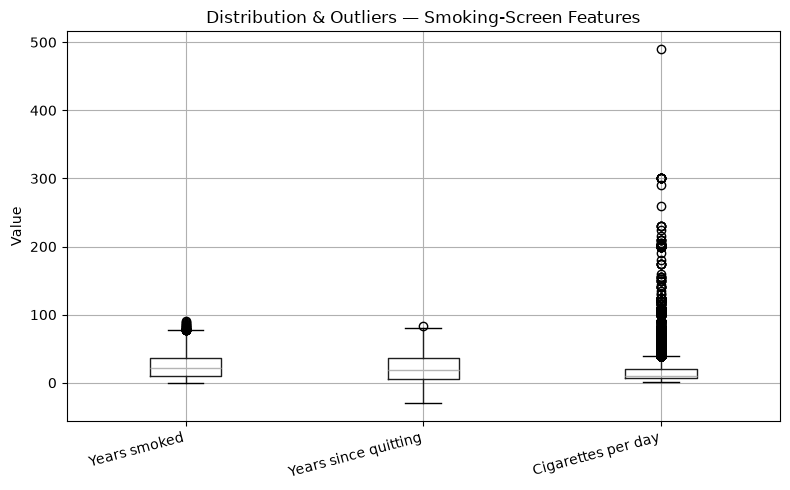

In [42]:
# Boxplot of the smoking-screen continuous features  (viz.plot_outlier_boxplot)
plot_outlier_boxplot(df)

### Observations:
All three smoking-screen features are heavily right-skewed, with their boxes compressed near the low end and long tails of high values flagged as outliers. The pattern is most extreme for cigarettes per day (LCSNUMCG), where a dense cluster of points stretches well above the upper fence. Because Alex's v2 preprocessing has already recoded BRFSS sentinel values, these represent genuine high self-reported smoking volumes rather than coded artifacts. No outlier treatment is applied: the skew reflects the real shape of the data, and the selected Random Forest is robust to extreme values.

### Multivariate Analysis

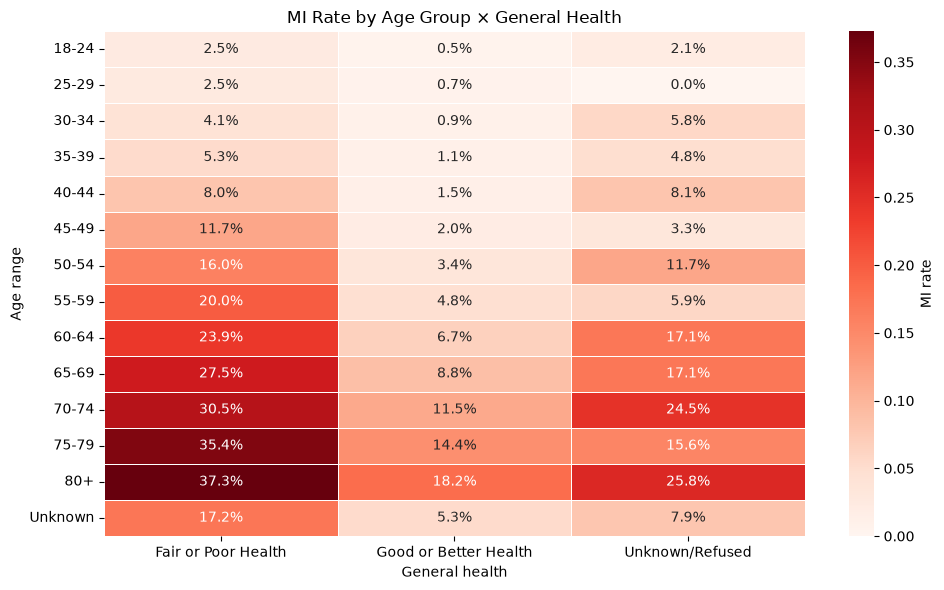

In [43]:
# MI rate across age group x general health  (viz.plot_age_health_interaction)
plot_age_health_interaction(df)

### Observations:
MI risk rises sharply with both age and poor health, climbing from under 1% for young, healthy respondents to over 35% for the oldest in fair/poor health.
The two factors compound, being both old and in poor health stacks risk far higher than either alone (the darkest cells are bottom-left).
The "old but healthy" cells sit in the middle, moderate risk where age and health pull in opposite directions, which is exactly the conflicting-signal zone that produces the model's borderline failures, as seen later in the notebook.

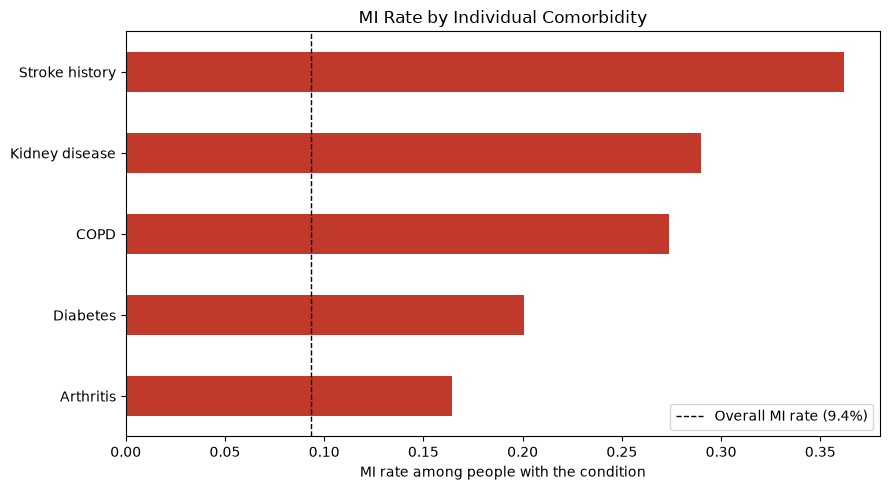

In [44]:
# MI rate among people with each individual comorbidity  (viz.plot_mi_by_comorbidity)
plot_mi_by_comorbidity(df)

### Observations:
Every chronic condition raises MI risk above the population baseline, with stroke history the strongest single marker at nearly four times the overall rate.
Every comorbidity raises MI risk above the 9.4% baseline, all five bars sit well to the right of the dashed overall-rate line.
Stroke history is the strongest single marker (~36%), nearly 4× the baseline, followed by kidney disease (~29%) and COPD (~27%), consistent with the ablation finding that stroke is the model's most irreplaceable feature, as seen later in the notebook.
Arthritis carries the lowest elevated risk (16%), reflecting its weaker cardiovascular link compared to the metabolic and vascular conditions above it.


## **6. Modeling Functions**
Modular, reusable functions for the modeling pipeline. Each model family
is trained through the same flow: build a preprocessor, assemble the
pipeline, undersample and fit, evaluate with cross-validation, and plot
results. `run_model` orchestrates the full sequence.

In [29]:
# All modeling functions now live in model_pipeline.py and were imported
# in the setup cell:
#   make_preprocessor, build_pipeline, train_pipeline,
#   evaluate_pipeline, plot_dashboard, run_model
# The train/test split is created here in the notebook so every section
# below shares the same X_train / X_test / y_train / y_test.
from sklearn.model_selection import train_test_split

X = df[FEATURES]   # the 27 selected features
y = df[TARGET]     # binary MI target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train / 20% test
    stratify=y,           # preserve the ~9% MI rate in both splits
    random_state=RANDOM_STATE,
)
print("train:", X_train.shape, "| test:", X_test.shape)

train: (361971, 27) | test: (90493, 27)


## **7. Train Models & Compare**
Train Logistic Regression, Random Forest, XGBoost; build the comparison table.

### Logistic Regression

=== Logistic Regression ===
CV AUC (5-fold): 0.8291 ± 0.0037
Test AUC: 0.8301 | Test AP: 0.3505

              precision    recall  f1-score   support

         0.0       0.97      0.74      0.84     82025
         1.0       0.23      0.76      0.36      8468

    accuracy                           0.74     90493
   macro avg       0.60      0.75      0.60     90493
weighted avg       0.90      0.74      0.79     90493



c:\Users\mfebu\Projects\mi-test\notebooks\../src\model_pipeline.py:281: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


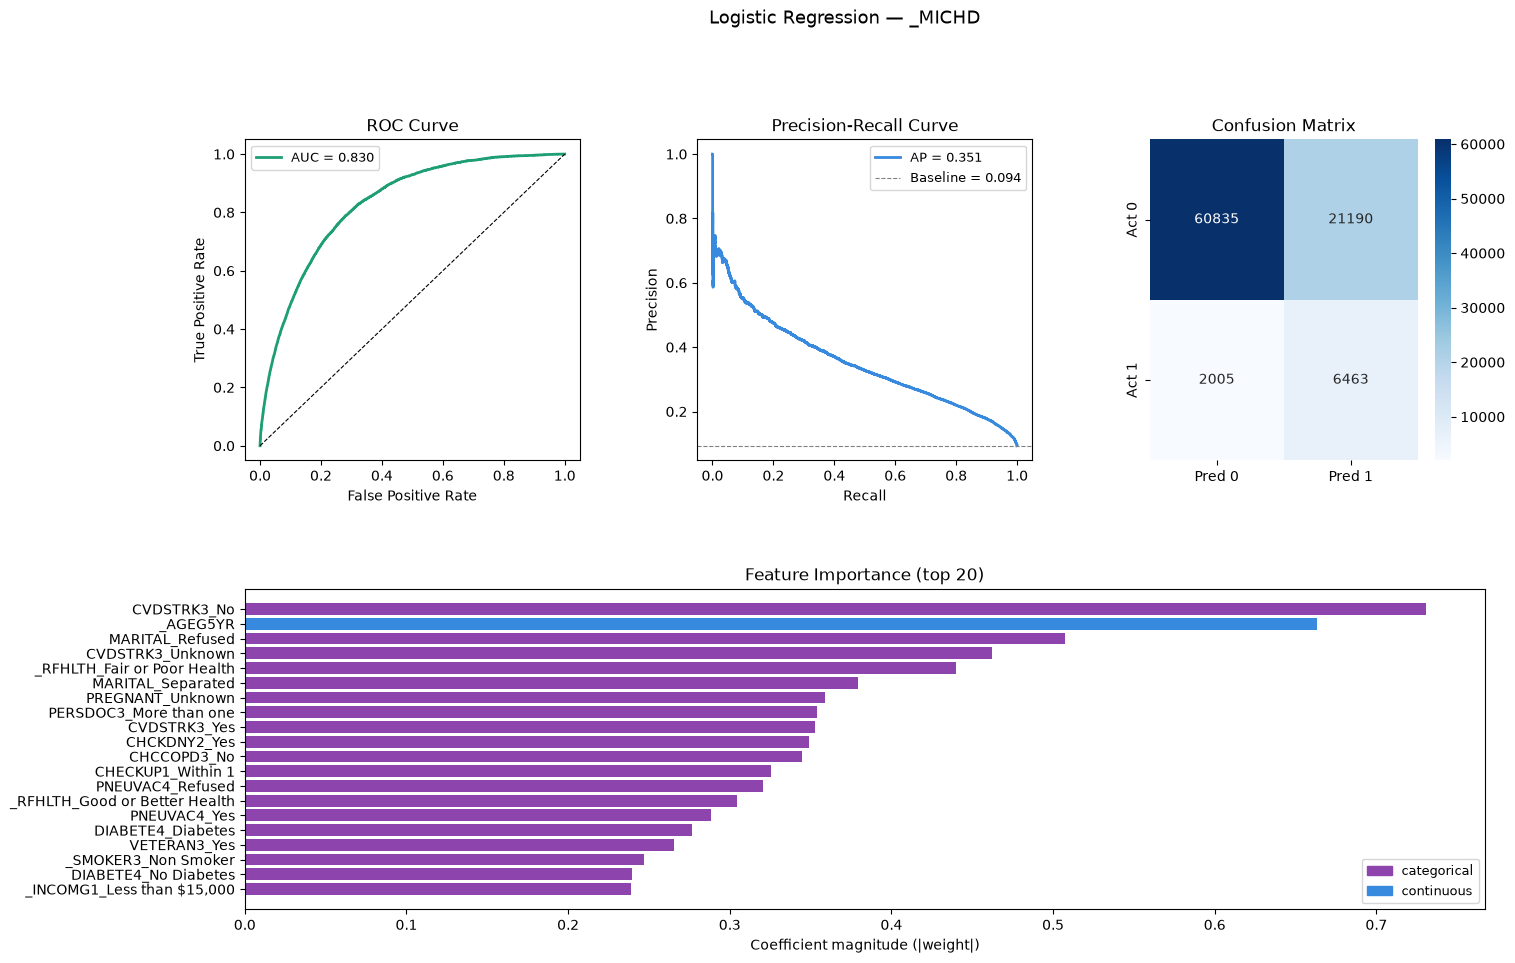

In [30]:
results = {}
results["lr"] = run_model(
    LogisticRegression(**LR_PARAMS), "Logistic Regression",
    X_train, y_train, X_test, y_test, cat_features, cont_features,
)

### Random Forest

=== Random Forest ===
CV AUC (5-fold): 0.8307 ± 0.0035
Test AUC: 0.8320 | Test AP: 0.3490

              precision    recall  f1-score   support

         0.0       0.97      0.71      0.82     82025
         1.0       0.22      0.80      0.35      8468

    accuracy                           0.72     90493
   macro avg       0.60      0.75      0.58     90493
weighted avg       0.90      0.72      0.78     90493



c:\Users\mfebu\Projects\mi-test\notebooks\../src\model_pipeline.py:281: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


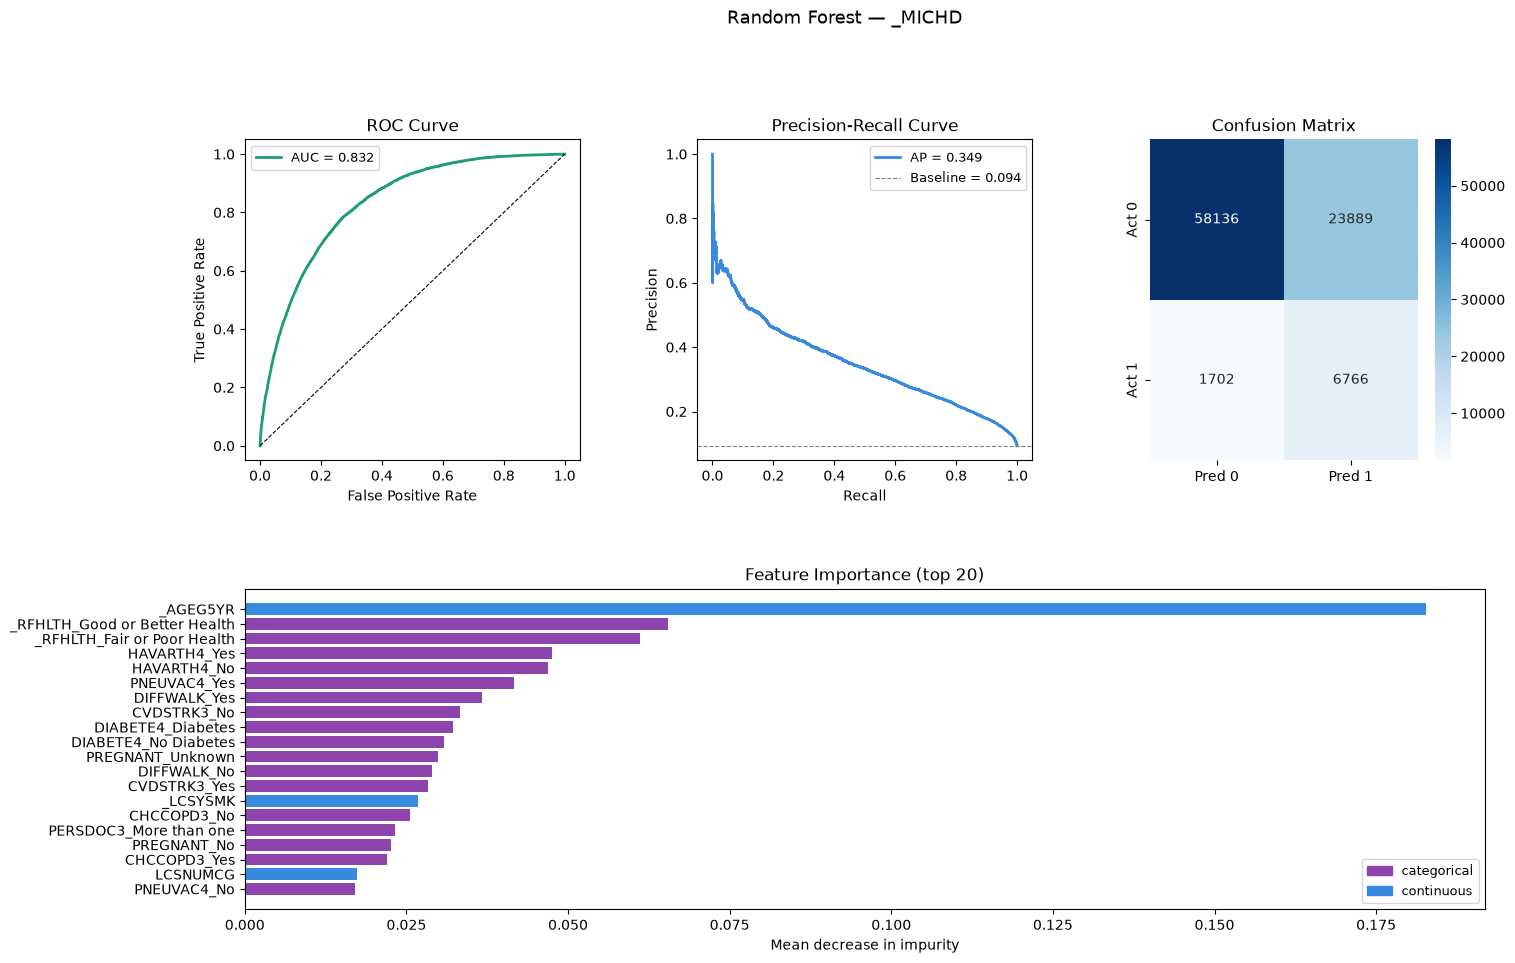

In [31]:
results["rf"] = run_model(
    RandomForestClassifier(**RF_PARAMS), "Random Forest",
    X_train, y_train, X_test, y_test, cat_features, cont_features,
)
results_rf = results["rf"]

### XGBoost

=== XGBoost ===
CV AUC (5-fold): 0.8263 ± 0.0038
Test AUC: 0.8288 | Test AP: 0.3342

              precision    recall  f1-score   support

         0.0       0.97      0.72      0.83     82025
         1.0       0.22      0.78      0.35      8468

    accuracy                           0.73     90493
   macro avg       0.60      0.75      0.59     90493
weighted avg       0.90      0.73      0.78     90493



c:\Users\mfebu\Projects\mi-test\notebooks\../src\model_pipeline.py:281: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


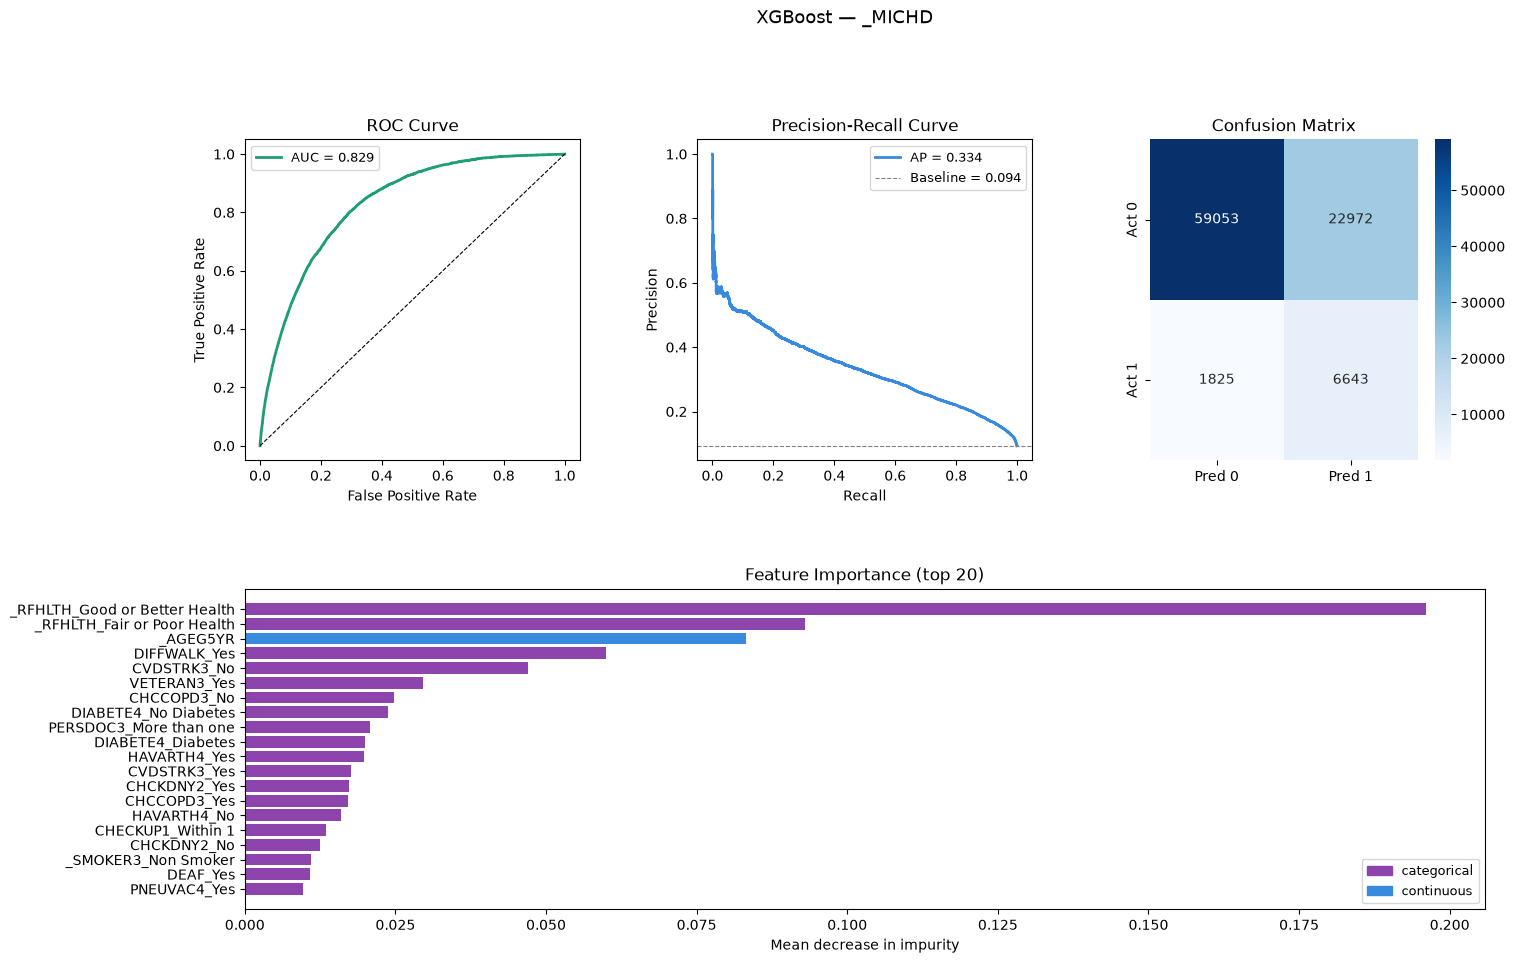

In [32]:
results["xgb"] = run_model(
    XGBClassifier(**XGB_PARAMS), "XGBoost",
    X_train, y_train, X_test, y_test, cat_features, cont_features,
)

### Model Comparison

In [33]:
comparison = pd.DataFrame([
    {
        "Model":     r["name"],
        "CV AUC":    round(r["cv_auc_mean"], 4),
        "Test AUC":  round(r["test_auc"], 4),
        "Test AP":   round(r["test_ap"], 4),
        "MI Recall": round(recall_score(y_test, r["y_pred"], pos_label=1), 4),
    }
    for r in results.values()
]).sort_values("Test AUC", ascending=False)

print(comparison.to_string(index=False))


              Model  CV AUC  Test AUC  Test AP  MI Recall
      Random Forest  0.8307    0.8320   0.3490     0.7990
Logistic Regression  0.8291    0.8301   0.3505     0.7632
            XGBoost  0.8263    0.8288   0.3342     0.7845


### Observations:
The three model families achieved very similar performance, with test ROC-AUC values ranging from 0.828 to 0.832, suggesting that model choice was not the primary factor limiting predictive performance. Instead, the available features appear to contain most of the predictive information that all three algorithms could exploit. Random Forest was selected as the final model because it achieved both the highest recall for the MI class (0.80), the primary metric for this screening application, and the highest overall test AUC (0.832). Logistic Regression performed nearly as well and achieved a slightly higher Average Precision (0.351), while offering the advantage of full interpretability. The comparable performance of the linear and tree-based models suggests that the predictive relationships in the data are captured reasonably well by all three approaches, with limited additional benefit from the more complex ensemble methods. Precision remained relatively low across all models (approximately 0.22–0.23), reflecting the expected tradeoff of prioritizing recall when training on an undersampled, highly imbalanced dataset.

## **7. In-Depth Analysis (Random Forest)**
Feature importance (SHAP beeswarm), ablation, sensitivity, and failure mode

### Feature Importance

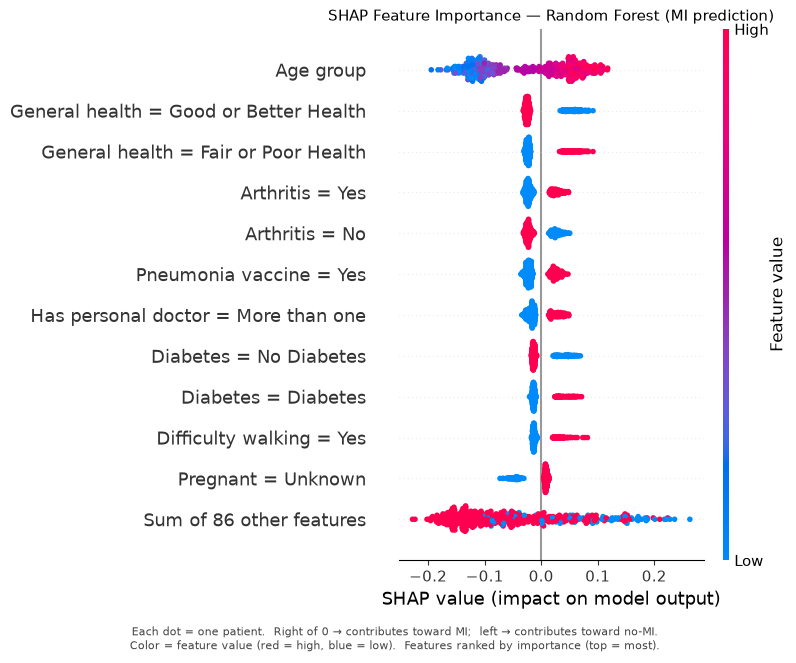

In [34]:
# Global SHAP feature importance for the Random Forest  (viz.plot_shap_beeswarm)
plot_shap_beeswarm(results["rf"], X_test)

### Observations:
Age group is the model's dominant predictor: older respondents (red) are pushed toward an MI prediction, younger ones (blue) away from it. General health follows the same clinically sensible pattern — fair or poor health raises the predicted risk, while good health lowers it. The next tier is a cluster of comorbidity and healthcare-engagement features (diabetes, arthritis, having a personal doctor, pneumonia vaccination), each contributing modestly. Primary insurance also ranks highly, largely as an age proxy, since Medicare eligibility begins at 65 and overlaps with the age signal. Overall, the model behaves as an age-and-health risk predictor, which both explains its strong recall and sets up its characteristic failures where those signals mislead.

## Feature Ablation

In [35]:
# Single-feature ablation: retrain the RF with each feature removed and
# rank by AUC impact  (model_pipeline.run_ablation)
ablation_feat_df = run_ablation(
    X_train, y_train, X_test, y_test, cat_features, cont_features,
)
print("\n=== Single-feature ablation, ranked by impact ===")
print(ablation_feat_df.to_string(index=False))

Baseline — full model: CV 0.8307 | Test 0.8320
  removed CHECKUP1      Test AUC 0.8320  ΔAUC -0.0001
  removed _TOTINDA      Test AUC 0.8323  ΔAUC +0.0003
  removed DIFFDRES      Test AUC 0.8323  ΔAUC +0.0002
  removed CHCOCNC1      Test AUC 0.8322  ΔAUC +0.0001
  removed _INCOMG1      Test AUC 0.8319  ΔAUC -0.0001
  removed VETERAN3      Test AUC 0.8311  ΔAUC -0.0010
  removed DIFFALON      Test AUC 0.8322  ΔAUC +0.0002
  removed _SMOKER3      Test AUC 0.8321  ΔAUC +0.0001
  removed PREGNANT      Test AUC 0.8320  ΔAUC +0.0000
  removed PERSDOC3      Test AUC 0.8287  ΔAUC -0.0034
  removed DEAF          Test AUC 0.8315  ΔAUC -0.0005
  removed MARITAL       Test AUC 0.8320  ΔAUC -0.0001
  removed PNEUVAC4      Test AUC 0.8318  ΔAUC -0.0002
  removed CHCKDNY2      Test AUC 0.8305  ΔAUC -0.0015
  removed HAVARTH4      Test AUC 0.8314  ΔAUC -0.0006
  removed DIABETE4      Test AUC 0.8295  ΔAUC -0.0025
  removed CHCCOPD3      Test AUC 0.8309  ΔAUC -0.0011
  removed CVDSTRK3      Test AUC 0.

### Observations:
Removing features one at a time shows that the model relies on a small handful of strong clinical predictors. Stroke history is the single most impactful feature, its removal causes the largest AUC drop (−0.0068), followed by age (−0.0055) and general health (−0.0051). Notably, although SHAP ranks age as the most important feature, ablation ranks stroke as the most irreplaceable: age has correlated proxies (Medicare, comorbidities) that substitute when it is removed, whereas stroke carries unique signal no other feature can replace. Beyond the top few predictors, the model is remarkably robust, removing almost any single remaining feature leaves AUC essentially unchanged, and a few even improve it marginally, indicating they add little signal. This concentration of predictive power in a few features is consistent with the model operating near the information ceiling of the available data.

## Sensitivity Analysis - Random Forest

   param_model__min_samples_leaf  mean_test_score  std_test_score
0                              1         0.811174        0.002665
1                              5         0.830893        0.002444
2                             10         0.831079        0.002509
3                             20         0.830748        0.002512
4                             50         0.829496        0.002525
5                            100         0.828118        0.002491


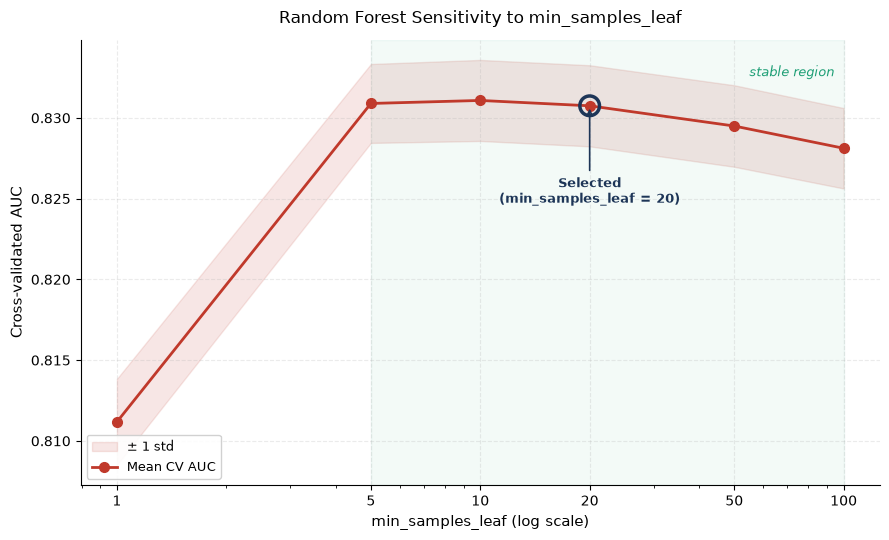

In [36]:
# Sweep min_samples_leaf, then plot CV-AUC stability
# (model_pipeline.sensitivity_min_samples_leaf -> viz.plot_sensitivity)
sens_res = sensitivity_min_samples_leaf(
    X_train, y_train, cat_features, cont_features,
)
print(sens_res)

plot_sensitivity(sens_res, selected=RF_PARAMS["min_samples_leaf"])

### Observations:
Sensitivity analysis on the random forest's min_samples_leaf parameter showed the model is robust across a wide range of values. Cross-validated AUC remained stable (~0.832) for leaf sizes from 5 through 50, degrading only at the extreme of min_samples_leaf = 1 (AUC 0.817), where trees split down to near-singleton leaves and overfit. The selected value of 20 falls comfortably within the stable region, confirming the model is not overly sensitive to this hyperparameter and is likely to generalize consistently.

## **8. Failure Analysis**


In [37]:
# Select three representative misclassified records (by rule, not by hand)
# and print them transposed  (viz.select_failure_records / print_failure_records)
ex1, ex2, ex3 = select_failure_records(results["rf"], X_test, y_test)
print_failure_records(ex1, ex2, ex3)


========== EX1_false_neg_young_lowrisk ==========
row index: 136021 | prob_MI: 0.025
                                  136021
CHECKUP1                        Within 1
_TOTINDA                             1.0
_LCSYQTS                             NaN
DIFFDRES                              No
CHCOCNC1                              No
_INCOMG1           $50,000 to < $100,000
VETERAN3                              No
DIFFALON                              No
_SMOKER3                      Non Smoker
PREGNANT                              No
LCSNUMCG                             NaN
PERSDOC3                             One
DEAF                                  No
MARITAL                    Never married
PNEUVAC4                              No
CHCKDNY2                              No
_LCSYSMK                             NaN
POORHLTH                             NaN
HAVARTH4                              No
PHYSHLTH                             NaN
DIABETE4                     No Diabetes
CHCCOPD3    

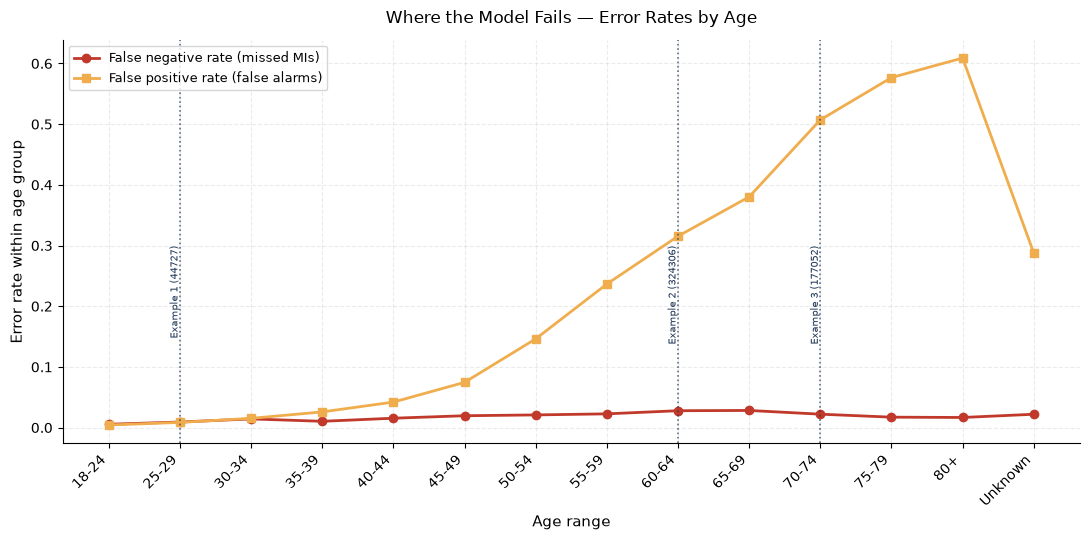

    Age  Misses (%)  False Alarms (%)    n
  18-24         0.5               0.4 5834
  25-29         0.9               0.9 4794
  30-34         1.4               1.5 5181
  35-39         1.0               2.6 5687
  40-44         1.5               4.2 6207
  45-49         2.0               7.5 5781
  50-54         2.1              14.6 6366
  55-59         2.3              23.7 6797
  60-64         2.8              31.5 8555
  65-69         2.8              38.0 9454
  70-74         2.2              50.7 8999
  75-79         1.7              57.7 7213
    80+         1.7              60.9 8033
Unknown         2.2              28.8 1592


In [38]:
# Error rates by age, with the three example records marked
# (viz.plot_failure_by_age)
by_age_display = plot_failure_by_age(results["rf"], X_test, y_test)

### Observations:
Mapping error rates across age reveals that the model's two failure modes are asymmetric. The false-negative rate (missed MIs) remains low and flat, at roughly 2% across all age groups, confirming that the recall-focused design rarely misses true cases regardless of age. The false-positive rate, by contrast, rises steeply with age, from under 1% among respondents aged 18–24 to over 60% among those 80 and older. This is the base-rate inflation effect made visible: because undersampling trained the model in a balanced world while the population is only ~9% positive, it over-flags older respondents, the majority of whom never had an MI. The three documented failure cases sit exactly where the pattern predicts, Example 1 in the flat low-error young region, and Examples 2 and 3 along the climbing false-alarm curve, confirming they are representative of systematic behavior rather than isolated anomalies.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=88479c56-07bc-4e04-92b4-d8345dc226f4' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>